In [34]:
!pip install requests pandas matplotlib fpdf validators beautifulsoup4 schedule --quiet

In [35]:
# OBRIŠI sve stare verzije (bitno!)
!pip uninstall -y fpdf fpdf2 --quiet

# Instaliraj samo fpdf2
!pip install fpdf2 --quiet

# Restart kernela ako treba (u Jupyter-u pokreni ovo jednom)
import sys
sys.modules.pop('fpdf', None)

# IMPORTI
import requests
import pandas as pd
import matplotlib.pyplot as plt
from fpdf import FPDF
from datetime import datetime
import time
import validators
import os
from bs4 import BeautifulSoup
import numpy as np

import schedule
import threading

In [36]:
def normalize_url(url):
    url = url.strip()
    
    if not url.startswith("http://") and not url.startswith("https://"):
        url = "https://" + url
    
    if validators.url(url):
        return url
    else:
        return None

urls_input = input("Unesite web sajtove odvojene zarezom:\n")
raw_urls = [url.strip() for url in urls_input.split(",") if url.strip() != ""]

urls = []
invalid_urls = []

for url in raw_urls:
    normalized = normalize_url(url)
    if normalized:
        urls.append(normalized)
    else:
        invalid_urls.append(url)

print(f"\nValidni URL-ovi:\n{urls}")

if invalid_urls:
    print(f"\nNevalidni URL-ovi (preskočeni):\n{invalid_urls}")

Unesite web sajtove odvojene zarezom:
 google.com, github.com, gigatron.rs



Validni URL-ovi:
['https://google.com', 'https://github.com', 'https://gigatron.rs']


In [37]:
def check_website(url, timeout=5):
    result = {"URL": url, "Status Code": None, "Response Time (s)": None, "Status": None}
    try:
        start = time.time()
        response = requests.get(url, timeout=timeout)
        end = time.time()
        
        result["Status Code"] = response.status_code
        result["Response Time (s)"] = round(end - start, 3)
        
        if response.status_code == 200:
            result["Status"] = "UP"
        elif response.status_code == 404:
            result["Status"] = "NOT FOUND"
        elif response.status_code >= 500:
            result["Status"] = "SERVER ERROR"
        else:
            result["Status"] = "UNKNOWN"
    except requests.exceptions.Timeout:
        result["Status"] = "DOWN (Timeout)"
    except requests.exceptions.RequestException:
        result["Status"] = "DOWN (Error)"
    
    return result

results = []

for url in urls:
    res = check_website(url)
    results.append(res)
    print(f"{res['URL']}: {res['Status']} ({res['Status Code']}) - {res['Response Time (s)']}s")

df_results = pd.DataFrame(results)
df_results

https://google.com: UP (200) - 1.014s
https://github.com: UP (200) - 0.195s
https://gigatron.rs: UP (200) - 0.073s


,URL,Status Code,Response Time (s),Status
0,https://google.com,200,1.014,UP
1,https://github.com,200,0.195,UP
2,https://gigatron.rs,200,0.073,UP


In [38]:
def calculate_score(row):
    if pd.isna(row['Response Time (s)']) or row['Response Time (s)'] == 0:
        return 0
    
    base_score = (1 / row['Response Time (s)']) * 100
    
    if row['Status'] != "UP":
        base_score *= 0.3
    
    return round(base_score, 2)

df_results['Performance Score'] = df_results.apply(calculate_score, axis=1)

df_results = df_results.sort_values(by='Performance Score', ascending=False).reset_index(drop=True)

print("\n🏆 PERFORMANCE RANKING:")
display(df_results[['URL', 'Status', 'Response Time (s)', 'Performance Score']])


🏆 PERFORMANCE RANKING:


,URL,Status,Response Time (s),Performance Score
0,https://gigatron.rs,UP,0.073,1369.86
1,https://github.com,UP,0.195,512.82
2,https://google.com,UP,1.014,98.62


In [40]:
HISTORY_FILE = "history.csv"

def save_history(df):
    df_copy = df.copy()
    df_copy["Timestamp"] = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    
    if os.path.exists(HISTORY_FILE):
        df_copy.to_csv(HISTORY_FILE, mode='a', header=False, index=False)
    else:
        df_copy.to_csv(HISTORY_FILE, index=False)

save_history(df_results)
print("📁 Istorija sačuvana")

def load_history():
    if os.path.exists(HISTORY_FILE):
        try:
            df_hist = pd.read_csv(HISTORY_FILE, on_bad_lines='skip')
            if "Timestamp" in df_hist.columns:
                df_hist["Timestamp"] = pd.to_datetime(df_hist["Timestamp"], errors='coerce')
            return df_hist
        except Exception as e:
            print(f"Greška pri učitavanju istorije: {e}")
            return pd.DataFrame()
    else:
        print("Nema istorije još.")
        return pd.DataFrame()

df_history = load_history()
df_history.head()

📁 Istorija sačuvana


,URL,Status Code,Response Time (s),Status,Performance Score,Timestamp
0,https://gigatron.rs,200.0,0.079,UP,1265.82,2026-04-07 16:22:45
1,https://github.com,200.0,0.197,UP,507.61,2026-04-07 16:22:45
2,https://google.com,200.0,0.566,UP,176.68,2026-04-07 16:22:45
3,https://sasaassas.com,NaN,NaN,DOWN (Error),0.00,2026-04-07 16:22:45
4,https://gigatron.rs,200.0,0.083,UP,1204.82,2026-04-07 16:27:02


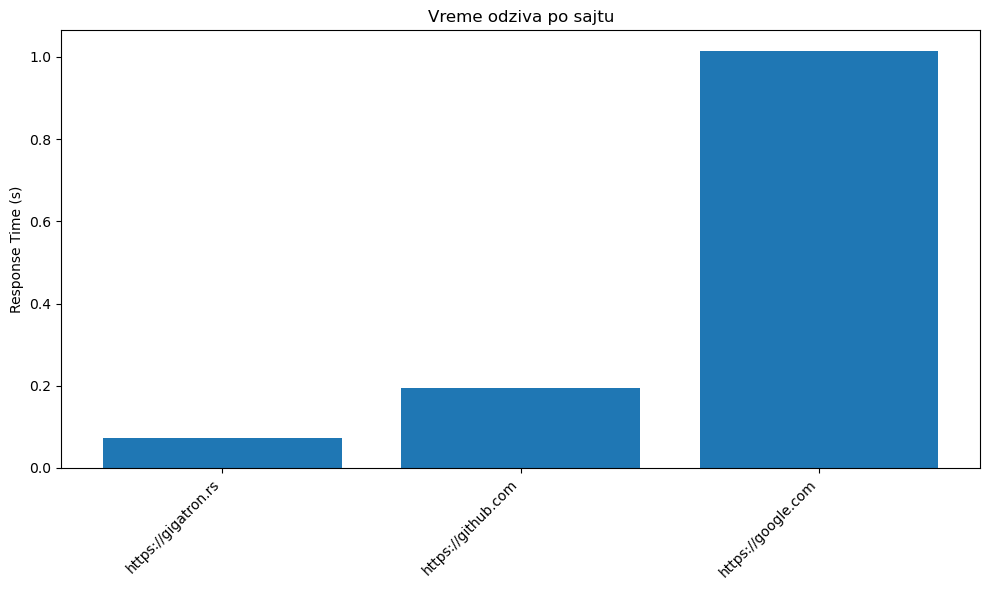

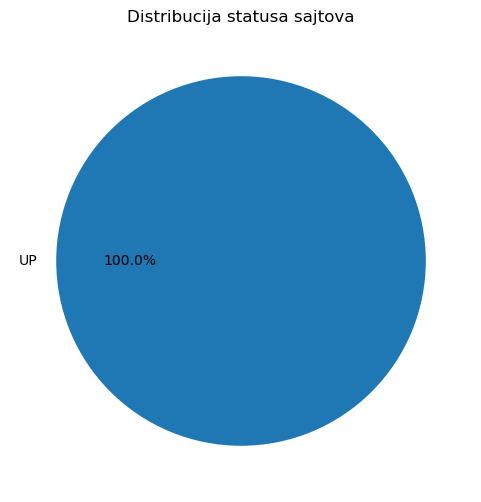

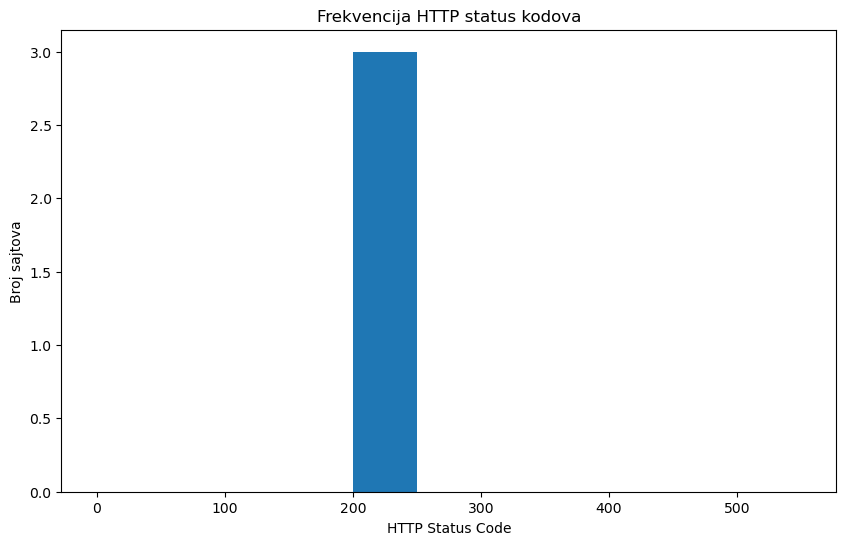

In [41]:
# Za Jupyter interaktivni prikaz
%matplotlib inline

import os
import matplotlib.pyplot as plt

os.makedirs("charts", exist_ok=True)

# Bar chart
plt.figure(figsize=(10,6))
plt.bar(df_results['URL'], df_results['Response Time (s)'].fillna(0))
plt.xticks(rotation=45, ha='right')
plt.ylabel('Response Time (s)')
plt.title('Vreme odziva po sajtu')
plt.tight_layout()
bar_path = "charts/bar_chart.png"
plt.show()

# Pie chart
status_counts = df_results['Status'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%')
plt.title('Distribucija statusa sajtova')
pie_path = "charts/pie_chart.png"
plt.savefig(pie_path)
plt.show()

# Histogram
plt.figure(figsize=(10,6))
status_codes = df_results['Status Code'].fillna(0)
plt.hist(status_codes, bins=range(0, 600, 50))
plt.xlabel('HTTP Status Code')
plt.ylabel('Broj sajtova')
plt.title('Frekvencija HTTP status kodova')
hist_path = "charts/hist_chart.png"
plt.savefig(hist_path)
plt.show()

In [42]:
def run_monitoring_job():
    print("\n⏱ Auto monitoring...\n")
    
    results = []
    for url in urls:
        res = check_website(url)
        results.append(res)
    
    df_auto = pd.DataFrame(results)
    df_auto['Performance Score'] = df_auto.apply(calculate_score, axis=1)
    
    save_history(df_auto)
    
    print("✅ Sačuvano u istoriji")

In [43]:
def start_scheduler(interval="5min"):
    schedule.clear()
    
    if interval == "1min":
        schedule.every(1).minutes.do(run_monitoring_job)
    elif interval == "5min":
        schedule.every(5).minutes.do(run_monitoring_job)
    elif interval == "1h":
        schedule.every(1).hours.do(run_monitoring_job)

    print(f"🚀 Scheduler pokrenut ({interval})")

    def run():
        while True:
            schedule.run_pending()
            time.sleep(1)

    t = threading.Thread(target=run)
    t.daemon = True
    t.start()

In [44]:
try:
    import schedule
except ImportError:
    !pip install schedule --quiet
    import schedule

print("\n⏰ Monitoring opcije:")
print("1 - 1 min")
print("2 - 5 min")
print("3 - 1h")

choice = input("Izbor: ")

if choice == "1":
    start_scheduler("1min")
elif choice == "2":
    start_scheduler("5min")
elif choice == "3":
    start_scheduler("1h")
else:
    print("Monitoring nije pokrenut")


⏰ Monitoring opcije:
1 - 1 min
2 - 5 min
3 - 1h


Izbor:  3


🚀 Scheduler pokrenut (1h)


In [47]:
try:
    while True:
        time.sleep(1)
except KeyboardInterrupt:
    print("🛑 Stopirano")

🛑 Stopirano


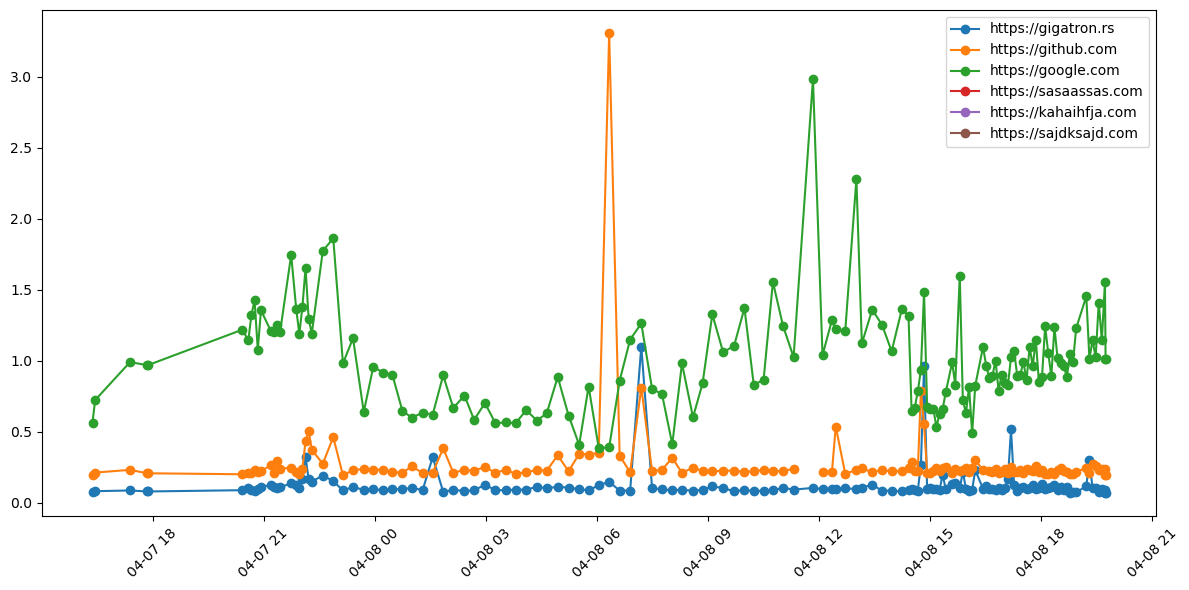

In [48]:
def plot_trend(df_history):
    if df_history.empty:
        print("Nema podataka za trend.")
        return None
    
    plt.figure(figsize=(12,6))
    
    for url in df_history['URL'].unique():
        df_url = df_history[df_history['URL'] == url].sort_values("Timestamp")
        plt.plot(df_url["Timestamp"], df_url["Response Time (s)"], marker='o', label=url)
    
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    
    trend_path = "charts/trend_chart.png"
    plt.savefig(trend_path)
    plt.show()
    
    return trend_path

trend_chart_path = plot_trend(df_history)


def seo_basic_analysis(url):
    try:
        resp = requests.get(url, timeout=5)
        soup = BeautifulSoup(resp.text, "html.parser")
        
        return pd.Series({
            "Has Title": bool(soup.title),
            "Has Meta Description": bool(soup.find("meta", attrs={"name":"description"})),
            "Page Size (KB)": round(len(resp.content)/1024,2),
            "Images": len(soup.find_all("img")),
            "Scripts": len(soup.find_all("script"))
        })
    except:
        return pd.Series([False, False, None, None, None])

seo_df = df_results['URL'].apply(seo_basic_analysis)
df_results = pd.concat([df_results, seo_df], axis=1)


# ✅ FIXED PDF (fpdf2 kompatibilan)
from fpdf import FPDF
from fpdf.enums import XPos, YPos

def generate_pdf(df, filename="website_report.pdf"):
    pdf = FPDF()
    pdf.add_page()

    # koristi helvetica (core font)
    pdf.set_font("helvetica", size=10)

    for _, row in df.iterrows():
        pdf.cell(
            0, 
            8, 
            f"{row['URL']} | {row['Status']} | {row['Performance Score']}",
            new_x=XPos.LMARGIN,
            new_y=YPos.NEXT
        )

    pdf.output(filename)
    print("✅ PDF kreiran!")

In [49]:
choice = input("Da li želite PDF? (yes/no): ").strip().lower()

if choice == "yes":
    generate_pdf(df_results)
else:
    print("PDF preskočen")

Da li želite PDF? (yes/no):  yes


✅ PDF kreiran!


In [ ]:
#dodao sam da mozes da biras vreme pokretanja sajta i ako ziabres npr 5min onda se sajt
#pokrece na svakih 5 minuta 